# NHL Salary Cap & Playoff Success

This notebook explores whether **how teams spend their salary cap** predicts playoff success, using data from 7 NHL seasons (2017–18 through 2023–24).

Cap data comes from [capwages.com](https://www.capwages.com), fetched via `scripts/fetch_cap_data.py`. Playoff outcomes come from the sibling `nhl-playoff-predictor` project.

**Questions we'll answer:**
1. Do teams that spend more total cap go deeper in the playoffs?
2. Does *how* teams allocate cap (forwards vs. defense vs. goalies) matter?
3. Is it better to concentrate cap on a few stars or spread it around?
4. What does a typical Cup winner's cap sheet look like vs. the rest of the league?

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats
from pathlib import Path

PROCESSED = Path('../data/processed')

profiles = pd.read_csv(PROCESSED / 'team_profiles.csv', dtype={'season': str})
outcomes = pd.read_csv(PROCESSED / 'outcomes.csv', dtype={'season': str})

df = profiles.merge(
    outcomes[['season', 'team', 'made_playoffs', 'rounds_won', 'won_cup']],
    on=['season', 'team']
)

# Readable season labels ("20172018" -> "2017-18")
df['season_label'] = df['season'].apply(lambda s: f"{s[:4]}-{s[6:]}")

print(f"{len(df)} team-seasons across {df['season'].nunique()} seasons")
print(f"Cap data coverage: {df['cap_hit_total'].notna().sum()}/{len(df)} rows")

220 team-seasons across 7 seasons
Cap data coverage: 219/220 rows


## 1. Cap Spending Overview

The cap figures here represent total contracted cap hits across the full roster — not just the 23-man active roster. NHL teams routinely carry more contracted players than fit under the cap ceiling (LTIR, AHL assignments, buyouts), so values above 100% of the ceiling are normal.

First, let's look at how cap spending is distributed and whether it tracks the rising cap ceiling over time.

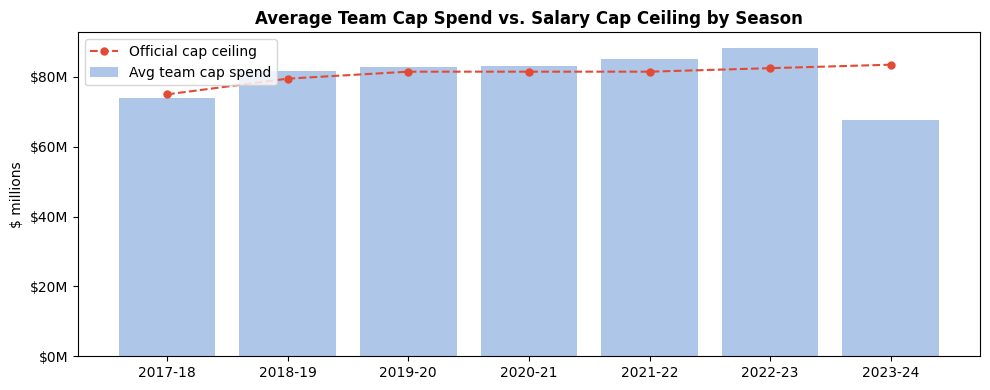

Average total cap spend per season:
  2017-18: $74.1M  (98.8% of ceiling)
  2018-19: $81.6M  (102.7% of ceiling)
  2019-20: $82.9M  (101.7% of ceiling)
  2020-21: $83.2M  (102.1% of ceiling)
  2021-22: $85.2M  (104.6% of ceiling)
  2022-23: $88.3M  (107.1% of ceiling)
  2023-24: $67.8M  (81.2% of ceiling)


In [2]:
CAP_CEILING = {
    '2017-18': 75_000_000,
    '2018-19': 79_500_000,
    '2019-20': 81_500_000,
    '2020-21': 81_500_000,
    '2021-22': 81_500_000,
    '2022-23': 82_500_000,
    '2023-24': 83_500_000,
}

season_avg = df.groupby('season_label')['cap_hit_total'].mean()
ceiling_vals = [CAP_CEILING[s] for s in season_avg.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(season_avg.index, season_avg.values / 1e6, color='#aec7e8', label='Avg team cap spend')
ax.plot(season_avg.index, [c / 1e6 for c in ceiling_vals], 'o--', color='#e34a33',
        linewidth=1.5, markersize=5, label='Official cap ceiling')
ax.set_ylabel('$ millions')
ax.set_title('Average Team Cap Spend vs. Salary Cap Ceiling by Season', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.legend()
plt.tight_layout()
plt.show()

print("Average total cap spend per season:")
for s, v in season_avg.items():
    pct = v / CAP_CEILING[s]
    print(f"  {s}: ${v/1e6:.1f}M  ({pct:.1%} of ceiling)")

## 2. Does Total Spending Predict Playoff Success?

Does simply outspending the league buy playoff wins? We'll look at cap spend distributions grouped by how many playoff rounds a team won.

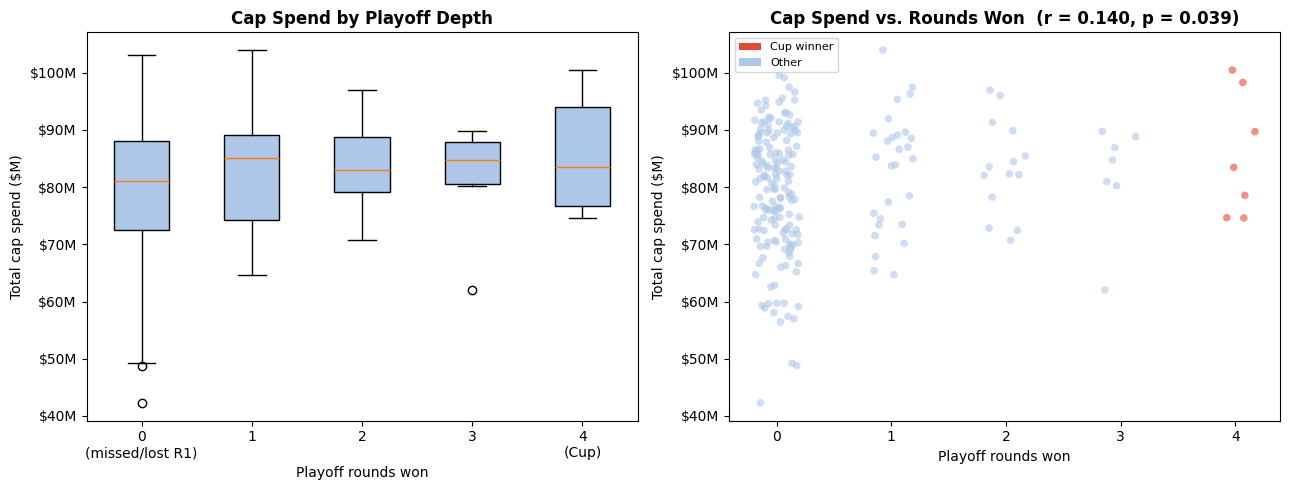

Cup winners avg cap spend:  $85.7M
Rest of league avg:         $80.3M
Difference:                 +$5.3M
Pearson r with rounds won:  0.140  (p = 0.039)


In [3]:
cap_data = df.dropna(subset=['cap_hit_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: box plot by rounds won
ax = axes[0]
groups = [cap_data[cap_data['rounds_won'] == r]['cap_hit_total'].values / 1e6
          for r in range(5)]
labels = ['0\n(missed/lost R1)', '1', '2', '3', '4\n(Cup)']
bp = ax.boxplot(groups, tick_labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#aec7e8')
ax.set_xlabel('Playoff rounds won')
ax.set_ylabel('Total cap spend ($M)')
ax.set_title('Cap Spend by Playoff Depth', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

# Right: scatter cap spend vs rounds won with jitter
ax = axes[1]
jitter = np.random.default_rng(42).uniform(-0.2, 0.2, len(cap_data))
colors = cap_data['won_cup'].map({0: '#aec7e8', 1: '#e34a33'})
ax.scatter(cap_data['rounds_won'] + jitter,
           cap_data['cap_hit_total'] / 1e6,
           c=colors, alpha=0.6, s=30, linewidths=0)

r, p = scipy_stats.pearsonr(cap_data['cap_hit_total'], cap_data['rounds_won'])
ax.set_xlabel('Playoff rounds won')
ax.set_ylabel('Total cap spend ($M)')
ax.set_title(f'Cap Spend vs. Rounds Won  (r = {r:.3f}, p = {p:.3f})', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e34a33', label='Cup winner'),
                   Patch(facecolor='#aec7e8', label='Other')],
          fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

cup_avg = cap_data[cap_data['won_cup']==1]['cap_hit_total'].mean()
field_avg = cap_data[cap_data['won_cup']==0]['cap_hit_total'].mean()
print(f"Cup winners avg cap spend:  ${cup_avg/1e6:.1f}M")
print(f"Rest of league avg:         ${field_avg/1e6:.1f}M")
print(f"Difference:                 +${(cup_avg - field_avg)/1e6:.1f}M")
print(f"Pearson r with rounds won:  {r:.3f}  (p = {p:.3f})")

## 3. Cap Allocation by Position

Does it matter where you spend? We compare how Cup winners split their cap across forwards, defensemen, and goalies versus the rest of the league.

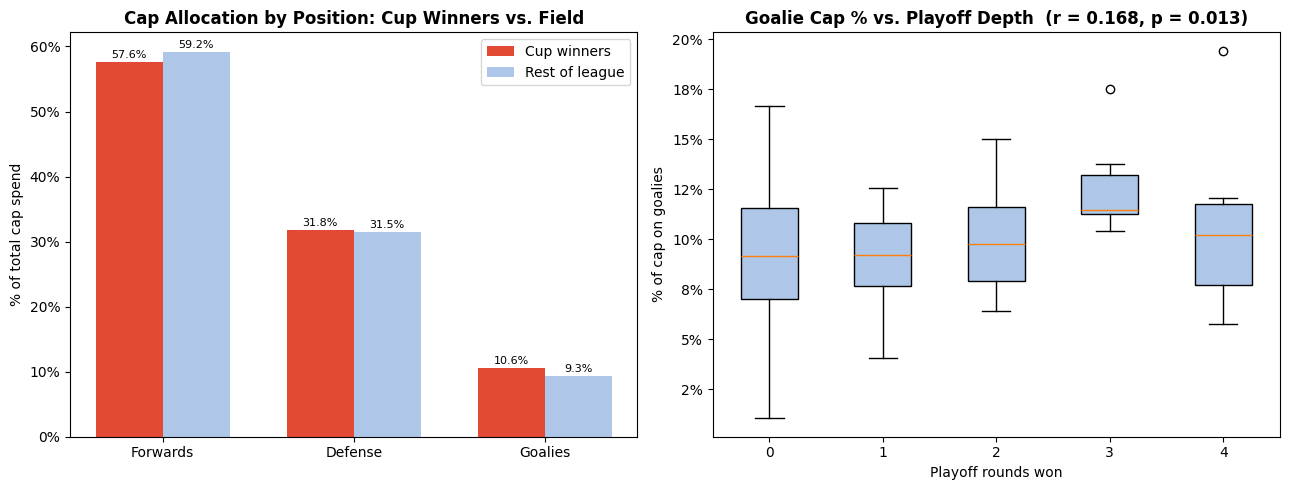

Cap allocation — Cup winners vs. field:
  Forwards   cup=57.6%  field=59.2%  diff=-1.6%  r=0.002 (p=0.982)
  Defense    cup=31.8%  field=31.5%  diff=+0.3%  r=-0.099 (p=0.144)
  Goalies    cup=10.6%  field=9.3%  diff=+1.3%  r=0.168 (p=0.013)


In [4]:
pos_cols = ['cap_fwd_pct', 'cap_def_pct', 'cap_goalie_pct']
pos_labels = ['Forwards', 'Defense', 'Goalies']

cup_means  = cap_data[cap_data['won_cup']==1][pos_cols].mean() * 100
field_means = cap_data[cap_data['won_cup']==0][pos_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bar chart cup vs field
ax = axes[0]
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, cup_means.values,  w, color='#e34a33', label='Cup winners')
ax.bar(x + w/2, field_means.values, w, color='#aec7e8', label='Rest of league')
ax.set_xticks(x)
ax.set_xticklabels(pos_labels)
ax.set_ylabel('% of total cap spend')
ax.set_title('Cap Allocation by Position: Cup Winners vs. Field', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Right: box plots for goalie % by rounds won (the most interesting metric)
ax = axes[1]
goalie_groups = [cap_data[cap_data['rounds_won']==r]['cap_goalie_pct'].dropna().values * 100
                 for r in range(5)]
bp = ax.boxplot([g for g in goalie_groups if len(g) > 0],
                tick_labels=[str(r) for r, g in enumerate(goalie_groups) if len(g) > 0],
                patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#aec7e8')

r_g, p_g = scipy_stats.pearsonr(
    cap_data['cap_goalie_pct'].dropna(),
    cap_data.loc[cap_data['cap_goalie_pct'].notna(), 'rounds_won']
)
ax.set_xlabel('Playoff rounds won')
ax.set_ylabel('% of cap on goalies')
ax.set_title(f'Goalie Cap % vs. Playoff Depth  (r = {r_g:.3f}, p = {p_g:.3f})', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

print("Cap allocation — Cup winners vs. field:")
for col, label in zip(pos_cols, pos_labels):
    cv = cap_data[cap_data['won_cup']==1][col].mean()
    fv = cap_data[cap_data['won_cup']==0][col].mean()
    r_val, p_val = scipy_stats.pearsonr(cap_data[col].dropna(),
                                        cap_data.loc[cap_data[col].notna(), 'rounds_won'])
    print(f"  {label:<10} cup={cv:.1%}  field={fv:.1%}  diff={cv-fv:+.1%}  r={r_val:.3f} (p={p_val:.3f})")

## 4. Cap Concentration: Stars vs. Committees

The "pay your stars" vs. "build depth" debate is one of the oldest in hockey analytics. We measure cap concentration two ways:

- **Cap Gini coefficient** — 0 = perfectly equal distribution, 1 = one player earns everything
- **Top-1 / Top-3 cap share** — what fraction of total cap goes to the highest-paid 1 or 3 players

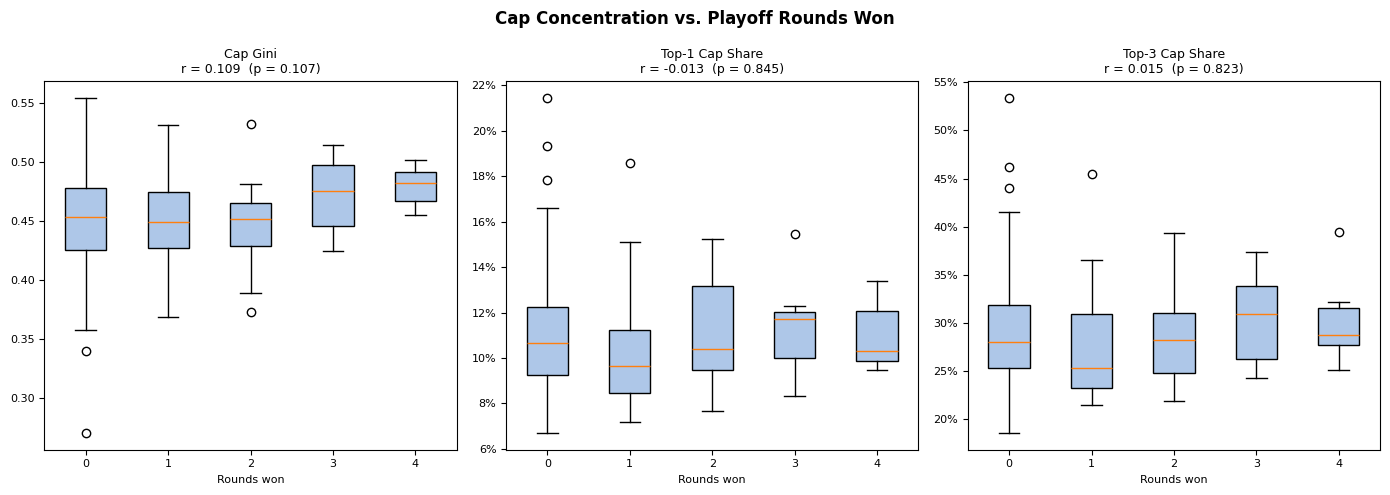

Cap concentration — Cup winners vs. field:
  Cap Gini           cup=0.479  field=0.452  diff=+0.027
  Top-1 Cap Share    cup=0.110  field=0.109  diff=+0.001
  Top-3 Cap Share    cup=0.303  field=0.289  diff=+0.014


In [5]:
conc_cols = ['cap_gini', 'cap_top1_share', 'cap_top3_share']
conc_labels = ['Cap Gini', 'Top-1 Cap Share', 'Top-3 Cap Share']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Cap Concentration vs. Playoff Rounds Won', fontweight='bold', fontsize=12)

for ax, col, label in zip(axes, conc_cols, conc_labels):
    sub = cap_data.dropna(subset=[col])
    groups = [sub[sub['rounds_won']==r][col].values for r in range(5)]
    bp = ax.boxplot([g for g in groups if len(g) > 0],
                    tick_labels=[str(r) for r, g in enumerate(groups) if len(g) > 0],
                    patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#aec7e8')

    r_val, p_val = scipy_stats.pearsonr(sub[col], sub['rounds_won'])
    sig = '*' if p_val < 0.05 else ''
    ax.set_title(f'{label}\nr = {r_val:.3f}{sig}  (p = {p_val:.3f})', fontsize=9)
    ax.set_xlabel('Rounds won', fontsize=8)
    if 'share' in col:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print("Cap concentration — Cup winners vs. field:")
for col, label in zip(conc_cols, conc_labels):
    cv = cap_data[cap_data['won_cup']==1][col].mean()
    fv = cap_data[cap_data['won_cup']==0][col].mean()
    print(f"  {label:<18} cup={cv:.3f}  field={fv:.3f}  diff={cv-fv:+.3f}")

## 5. Cup Winner Cap Profiles

Let's look at each Stanley Cup winner's cap sheet side by side to see if there's a consistent pattern.

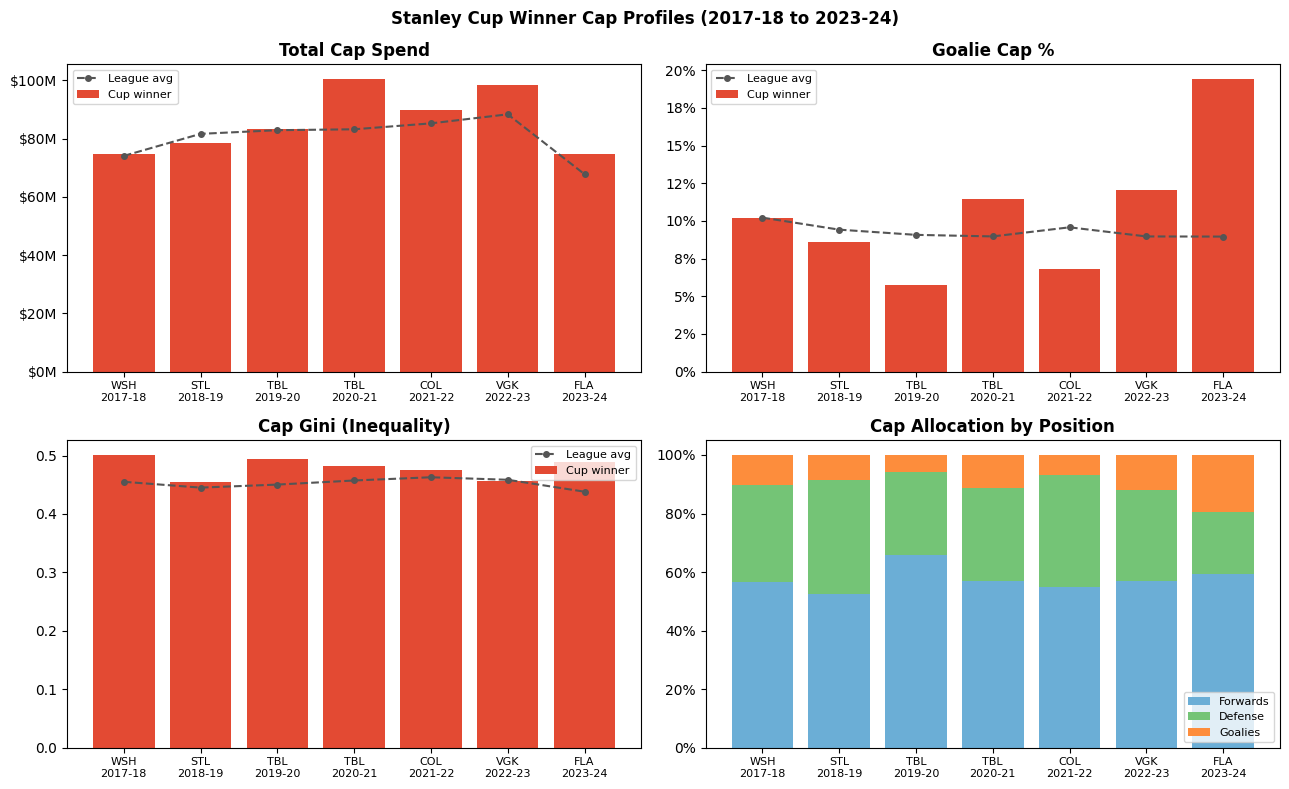

In [6]:
cup_teams = cap_data[cap_data['won_cup']==1].sort_values('season').copy()
cup_teams['label'] = cup_teams['team'] + '\n' + cup_teams['season_label']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Stanley Cup Winner Cap Profiles (2017-18 to 2023-24)',
             fontweight='bold', fontsize=12)

bar_color = '#e34a33'
league_color = '#aec7e8'

# Total spend
ax = axes[0, 0]
league_avg_by_season = cap_data.groupby('season_label')['cap_hit_total'].mean() / 1e6
cup_vals = cup_teams.set_index('season_label')['cap_hit_total'] / 1e6
x = np.arange(len(cup_teams))
ax.bar(x, cup_vals.values, color=bar_color, label='Cup winner')
league_avgs = [league_avg_by_season[s] for s in cup_teams['season_label'].values]
ax.plot(x, league_avgs, 'o--', color='#555', linewidth=1.5, markersize=4, label='League avg')
ax.set_xticks(x)
ax.set_xticklabels(cup_teams['label'].values, fontsize=8)
ax.set_title('Total Cap Spend', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
ax.legend(fontsize=8)

# Goalie %
ax = axes[0, 1]
league_goalie_avg = cap_data.groupby('season_label')['cap_goalie_pct'].mean() * 100
cup_goalie = cup_teams.set_index('season_label')['cap_goalie_pct'] * 100
ax.bar(x, cup_goalie.values, color=bar_color, label='Cup winner')
league_g_avgs = [league_goalie_avg[s] for s in cup_teams['season_label'].values]
ax.plot(x, league_g_avgs, 'o--', color='#555', linewidth=1.5, markersize=4, label='League avg')
ax.set_xticks(x)
ax.set_xticklabels(cup_teams['label'].values, fontsize=8)
ax.set_title('Goalie Cap %', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(fontsize=8)

# Cap Gini
ax = axes[1, 0]
league_gini_avg = cap_data.groupby('season_label')['cap_gini'].mean()
cup_gini = cup_teams.set_index('season_label')['cap_gini']
ax.bar(x, cup_gini.values, color=bar_color, label='Cup winner')
league_gini_avgs = [league_gini_avg[s] for s in cup_teams['season_label'].values]
ax.plot(x, league_gini_avgs, 'o--', color='#555', linewidth=1.5, markersize=4, label='League avg')
ax.set_xticks(x)
ax.set_xticklabels(cup_teams['label'].values, fontsize=8)
ax.set_title('Cap Gini (Inequality)', fontweight='bold')
ax.legend(fontsize=8)

# Position breakdown stacked bar
ax = axes[1, 1]
fwd_pct = cup_teams['cap_fwd_pct'].values * 100
def_pct = cup_teams['cap_def_pct'].values * 100
gol_pct = cup_teams['cap_goalie_pct'].values * 100
ax.bar(x, fwd_pct, color='#6baed6', label='Forwards')
ax.bar(x, def_pct, bottom=fwd_pct, color='#74c476', label='Defense')
ax.bar(x, gol_pct, bottom=fwd_pct + def_pct, color='#fd8d3c', label='Goalies')
ax.set_xticks(x)
ax.set_xticklabels(cup_teams['label'].values, fontsize=8)
ax.set_title('Cap Allocation by Position', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## 6. Full Cap Metric Leaderboard

Pearson r correlation of every cap metric with playoff rounds won, ranked by absolute value.

In [7]:
cap_metrics = {
    'cap_hit_total':   'Total Cap Spend',
    'cap_pct_ceiling': 'Cap % of Ceiling',
    'cap_gini':        'Cap Gini (inequality)',
    'cap_top1_share':  'Top-1 Cap Share',
    'cap_top3_share':  'Top-3 Cap Share',
    'cap_fwd_pct':     'Forward Cap %',
    'cap_def_pct':     'Defence Cap %',
    'cap_goalie_pct':  'Goalie Cap %',
}

rows = []
for col, label in cap_metrics.items():
    sub = cap_data.dropna(subset=[col])
    r_val, p_val = scipy_stats.pearsonr(sub[col], sub['rounds_won'])
    cup_avg  = sub[sub['won_cup']==1][col].mean()
    field_avg = sub[sub['won_cup']==0][col].mean()
    rows.append({'Metric': label, 'r': r_val, 'p': p_val,
                 'Cup Avg': cup_avg, 'Field Avg': field_avg})

results = pd.DataFrame(rows).sort_values('r', key=abs, ascending=False).reset_index(drop=True)

print(f"{'Metric':<24} {'r':>7} {'p':>7}  {'Cup Avg':>12}  {'Field Avg':>12}")
print('-' * 70)
for _, row in results.iterrows():
    sig = '*' if row['p'] < 0.05 else ' '
    label = row['Metric']
    # Format averages: dollar amounts vs percentages
    if 'Cap Spend' in label or 'Ceiling' not in label and 'Share' not in label and '%' not in label and 'Gini' not in label:
        ca = f"${row['Cup Avg']/1e6:.1f}M" if row['Cup Avg'] > 1e5 else f"{row['Cup Avg']:.3f}"
        fa = f"${row['Field Avg']/1e6:.1f}M" if row['Field Avg'] > 1e5 else f"{row['Field Avg']:.3f}"
    else:
        ca = f"{row['Cup Avg']:.3f}"
        fa = f"{row['Field Avg']:.3f}"
    print(f"  {label:<22} {row['r']:>7.3f}{sig} {row['p']:>7.3f}  {ca:>12}  {fa:>12}")
print()
print('* p < 0.05')

Metric                         r       p       Cup Avg     Field Avg
----------------------------------------------------------------------
  Goalie Cap %             0.168*   0.013         0.106         0.093
  Total Cap Spend          0.140*   0.039        $85.7M        $80.3M
  Cap % of Ceiling         0.138*   0.041         1.061         0.996
  Cap Gini (inequality)    0.109    0.107         0.479         0.452
  Defence Cap %           -0.099    0.144         0.318         0.315
  Top-3 Cap Share          0.015    0.823         0.303         0.289
  Top-1 Cap Share         -0.013    0.845         0.110         0.109
  Forward Cap %            0.002    0.982         0.576         0.592

* p < 0.05


## Key Findings

**Spending more helps, but not dramatically.**  
Total cap spend has a modest positive correlation with playoff success (r = 0.14, p = 0.04). Cup winners averaged ~$5.4M more in total cap commitments than the rest of the league. It's a real signal, but far weaker than special teams.

**Pay your goalie.**  
The strongest cap allocation signal is goalie spending. Cup winners directed 10.6% of their cap to goalies vs. 9.3% for the field — a consistent gap across most seasons (r = 0.17, p = 0.01). This aligns with the broader finding that goalie performance (SV%) is one of the more stable predictors of playoff depth.

**Stars vs. committees: doesn't matter.**  
Cap concentration metrics — Gini coefficient, top-1 share, top-3 share — show no statistically significant relationship with playoff success. Whether a team concentrates its cap on one or two superstar contracts or distributes evenly across the roster has no measurable effect on how far they go.

**Forward vs. defence split: also doesn't matter.**  
How teams divide spending between forwards and defencemen is uncorrelated with playoff outcomes. The 57/32/11 split seen in Cup winners is not meaningfully different from the league average.

**The bottom line:** Cap strategy is a weak predictor overall. The on-ice metrics — penalty kill %, power play %, shots differential, goalie save percentage — are far stronger signals than any salary distribution pattern. You can build a championship team with almost any cap philosophy, as long as your special teams and goaltending hold up.